# SRModel — Clean notebook (maze-node SR + Explorer/Systematic)
This notebook:
1) loads `*-tf` files
2) reconstructs **maze node trajectory** from `no` (each element is `[start,end]`)
3) computes behavioral metrics + Explorer/Systematic label
4) computes SR on maze nodes and plots exemplar heatmaps + group average heatmaps


In [11]:

import os, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

OUTDATA_DIR = r"outdata"
EXCLUDE = {"D6-tf","A1a-tf","A1b-tf","D7a-tf","D7b-tf","D9a-tf","D9b-tf","F2a-tf","F2b-tf"}  # adjust if needed
GAMMA = 0.90
RIDGE = 1e-6
EPS = 1e-12

print("cwd:", os.getcwd())
print("OUTDATA_DIR exists?", os.path.exists(OUTDATA_DIR))


cwd: c:\PBM\MouseMaze
OUTDATA_DIR exists? True


## 1) Loader (handles missing MM_Traj_Utils)


In [12]:

class DummyClass:
    def __init__(self, *args, **kwargs):
        pass
    def __setstate__(self, state):
        if isinstance(state, dict):
            self.__dict__.update(state)

class SelectiveUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("MM_Traj_Utils"):
            return DummyClass
        return super().find_class(module, name)

def load_pickle(path):
    with open(path, "rb") as f:
        try:
            return pickle.load(f)
        except ModuleNotFoundError:
            f.seek(0)
            return SelectiveUnpickler(f).load()


## 2) Data parsing
`no` is stored as *segments* of shape (1,2) like `[[start end]]`.
We convert it into a node trajectory: `start → end → end → ...`


In [13]:
def extract_maze_nodes_from_ce(mouse_data):
    ce_data = getattr(mouse_data, "ce", None)
    if ce_data is None:
        raise ValueError("Missing 'ce' in mouse_data")

    nodes = []
    for arr in ce_data:
        if arr is None:
            continue
        a = np.array(arr).reshape(-1)
        nodes.extend(a.tolist())

    nodes = np.array(nodes, dtype=float)
    nodes = nodes[~np.isnan(nodes)].astype(int)

    return nodes

def is_real_mouse(fname: str) -> bool:
    if fname in EXCLUDE:
        return False
    if "MarkovSim" in fname:
        return False
    if "RW" in fname:
        return False
    if fname.lower().startswith("rw"):
        return False
    return "-tf" in fname


## 3) Metrics (maze nodes)
We compute metrics on the **maze-node trajectory**.


In [14]:

def remap_to_compact(seq):
    uniq = np.unique(seq)
    mapping = {old:i for i, old in enumerate(uniq)}
    new = np.array([mapping[x] for x in seq], dtype=int)
    return new, mapping, uniq  # uniq maps compact-id -> original node id

def build_transition_matrix(seq, n_states):
    # NOTE: this is the version used by the dataframe pipeline (accepts n_states keyword)
    counts = np.zeros((n_states, n_states), dtype=float)
    for a, b in zip(seq[:-1], seq[1:]):
        if a == b:
            continue
        counts[a, b] += 1.0
    row = counts.sum(axis=1, keepdims=True)
    P = np.divide(counts, row, where=row != 0)
    return P

def transition_entropy(P):
    H = -np.sum(P * np.log(P + EPS), axis=1)
    H = H[np.isfinite(H)]
    return float(np.mean(H)) if len(H) else np.nan

def backtracking_ratio(seq):
    if len(seq) < 3:
        return np.nan
    return float(np.mean(seq[2:] == seq[:-2]))

def novelty_auc(seq):
    seen = set()
    frac = []
    for i, s in enumerate(seq, start=1):
        seen.add(int(s))
        frac.append(len(seen) / i)
    return float(np.mean(frac))

def early_discovery_rate(seq, window=2000):
    w = min(window, len(seq))
    if w == 0:
        return np.nan
    return float(len(set(seq[:w])) / w)


## 4) Run across mice → dataframe


In [15]:

all_paths = sorted(glob.glob(os.path.join(OUTDATA_DIR, "*")))
paths = [p for p in all_paths if is_real_mouse(os.path.basename(p))]
print("Candidate mice:", len(paths))
print([os.path.basename(p) for p in paths[:15]])

rows = []
traj_cache = {}   # original maze-node trajectory per mouse (for SR later)

for p in paths:
    fname = os.path.basename(p)
    try:
        obj = load_pickle(p)
        nodes = extract_maze_nodes_from_ce(obj)
        traj_cache[fname] = nodes

        seq, mapping, uniq_nodes = remap_to_compact(nodes)
        n_states = len(mapping)

        P = build_transition_matrix(seq, n_states=n_states)

        rows.append({
            "id": fname,
            "letter": fname[0],
            "n_events": int(len(seq)),
            "n_states_visited": int(n_states),
            "node_min": int(nodes.min()) if len(nodes) else np.nan,
            "node_max": int(nodes.max()) if len(nodes) else np.nan,
            "entropy": transition_entropy(P),
            "backtrack": backtracking_ratio(seq),
            "novelty_auc": novelty_auc(seq),
            "early_discovery_rate": early_discovery_rate(seq, window=2000),
        })
    except Exception as e:
        print("Skipping", fname, "->", repr(e))

df = pd.DataFrame(rows).set_index("id").sort_index()
df


Candidate mice: 19
['B1-tf', 'B2-tf', 'B3-tf', 'B4-tf', 'B5-tf', 'B6-tf', 'B7-tf', 'C1-tf', 'C3-tf', 'C6-tf', 'C7-tf', 'C8-tf', 'C9-tf', 'D3-tf', 'D4-tf']


,letter,n_events,n_states_visited,node_min,node_max,entropy,backtrack,novelty_auc,early_discovery_rate
id,,,,,,,,,
B1-tf,B,255223,176,0,175,0.548398,0.847595,0.002142,0.0010
B2-tf,B,353503,176,0,175,0.555178,0.841701,0.002346,0.0245
B3-tf,B,189343,176,0,175,0.551094,0.811383,0.003300,0.0050
B4-tf,B,430623,176,0,175,0.554216,0.837179,0.001889,0.0190
B5-tf,B,337643,176,0,175,0.557856,0.806336,0.002444,0.0305
B6-tf,B,349646,176,0,175,0.551230,0.807956,0.002348,0.0270
B7-tf,B,294008,176,0,175,0.547702,0.833544,0.002235,0.0190
C1-tf,C,322126,176,0,175,0.560509,0.805972,0.002472,0.0180
C3-tf,C,344160,176,0,175,0.552916,0.769344,0.002301,0.0225


## 5) Label Explorer vs Systematic (based on novelty)
Top tercile of novelty_auc → Explorer.


In [16]:

thr = np.nanpercentile(df["novelty_auc"], 67)
df["style"] = np.where(df["novelty_auc"] >= thr, "Explorer", "Systematic")

print("Novelty threshold (67th percentile):", thr)
print(df["style"].value_counts())
print("\nBy letter:")
print(pd.crosstab(df["style"], df["letter"]))
df


Novelty threshold (67th percentile): 0.0023037099900263262
style
Systematic    13
Explorer       6
Name: count, dtype: int64

By letter:
letter      B  C  D
style              
Explorer    4  1  1
Systematic  3  5  5


,letter,n_events,n_states_visited,node_min,node_max,entropy,backtrack,novelty_auc,early_discovery_rate,style
id,,,,,,,,,,
B1-tf,B,255223,176,0,175,0.548398,0.847595,0.002142,0.0010,Systematic
B2-tf,B,353503,176,0,175,0.555178,0.841701,0.002346,0.0245,Explorer
B3-tf,B,189343,176,0,175,0.551094,0.811383,0.003300,0.0050,Explorer
B4-tf,B,430623,176,0,175,0.554216,0.837179,0.001889,0.0190,Systematic
B5-tf,B,337643,176,0,175,0.557856,0.806336,0.002444,0.0305,Explorer
B6-tf,B,349646,176,0,175,0.551230,0.807956,0.002348,0.0270,Explorer
B7-tf,B,294008,176,0,175,0.547702,0.833544,0.002235,0.0190,Systematic
C1-tf,C,322126,176,0,175,0.560509,0.805972,0.002472,0.0180,Explorer
C3-tf,C,344160,176,0,175,0.552916,0.769344,0.002301,0.0225,Systematic


## 6) SR on maze nodes
We build SR on a **global node set** so matrices align across mice.
We use ridge regularization to stabilize inversion.


In [17]:

def build_P_global(nodes, n_nodes_global):
    counts = np.zeros((n_nodes_global, n_nodes_global), dtype=float)
    for a, b in zip(nodes[:-1], nodes[1:]):
        if a == b:
            continue
        if 0 <= a < n_nodes_global and 0 <= b < n_nodes_global:
            counts[a, b] += 1.0
    row = counts.sum(axis=1, keepdims=True)
    P = np.divide(counts, row, where=row != 0)
    return P

def successor_representation(P, gamma=0.9, ridge=1e-6):
    n = P.shape[0]
    A = np.eye(n) - gamma * P
    A = A + ridge * np.eye(n)
    return np.linalg.inv(A)

# choose global node count as max observed node + 1
global_max = int(df["node_max"].max())
N_GLOBAL = global_max + 1
print("Global node count:", N_GLOBAL, "(0..", global_max, ")")


Global node count: 176 (0.. 175 )


## 7) Pick exemplar mice (most extreme novelty)


In [18]:

ex_id = df[df["style"]=="Explorer"].sort_values("novelty_auc", ascending=False).index[0]
sy_id = df[df["style"]=="Systematic"].sort_values("novelty_auc", ascending=True).index[0]
print("Explorer exemplar:", ex_id)
print("Systematic exemplar:", sy_id)


Explorer exemplar: B3-tf
Systematic exemplar: C8-tf


## 8) Heatmaps like your first one (Explorer vs Systematic)
No reordering. Same axes = node IDs.


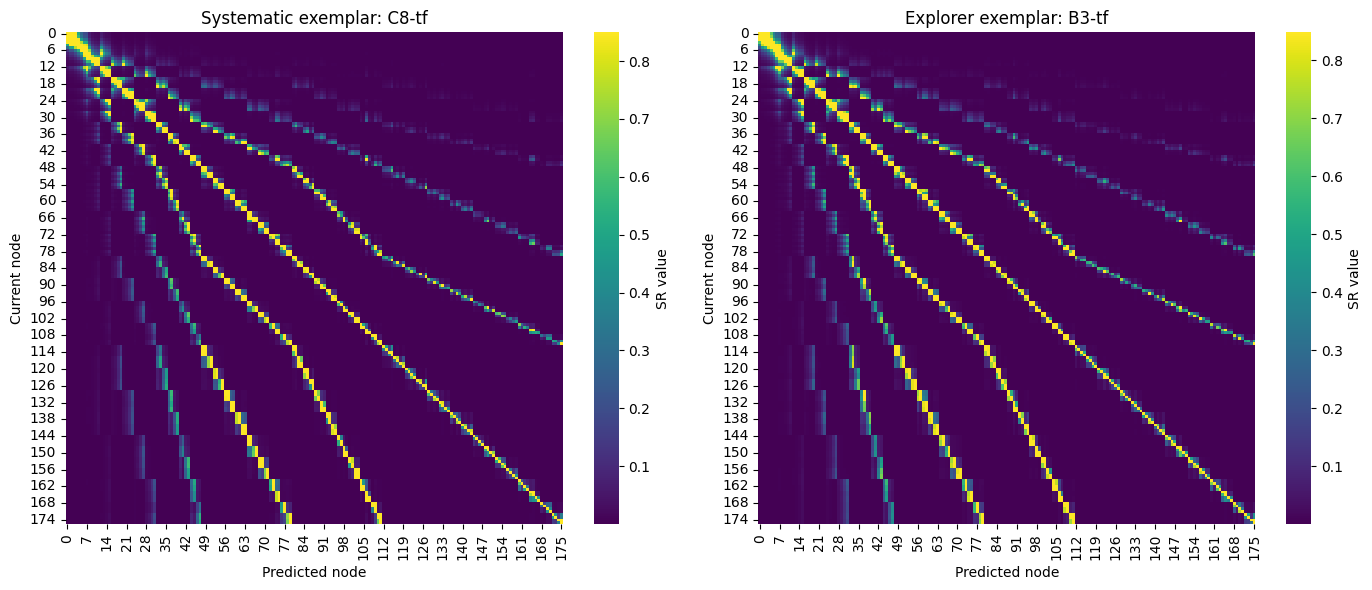

In [19]:

def sr_for_mouse(mouse_id):
    nodes = traj_cache[mouse_id]
    P = build_P_global(nodes, N_GLOBAL)
    M = successor_representation(P, gamma=GAMMA, ridge=RIDGE)
    return M

M_ex = sr_for_mouse(ex_id)
M_sy = sr_for_mouse(sy_id)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.heatmap(M_sy, cmap="viridis", robust=True, cbar_kws={"label":"SR value"})
plt.title(f"Systematic exemplar: {sy_id}")
plt.xlabel("Predicted node")
plt.ylabel("Current node")

plt.subplot(1,2,2)
sns.heatmap(M_ex, cmap="viridis", robust=True, cbar_kws={"label":"SR value"})
plt.title(f"Explorer exemplar: {ex_id}")
plt.xlabel("Predicted node")
plt.ylabel("Current node")

plt.tight_layout()
plt.show()


In [20]:
obj = load_pickle(os.path.join(OUTDATA_DIR, "C3-tf"))
nodes = extract_maze_nodes_from_ce(obj)

print("len:", len(nodes))
print("range:", nodes.min(), nodes.max())
print("unique:", len(np.unique(nodes)))
print("first 20:", nodes[:20])

len: 344160
range: 0 175
unique: 176
first 20: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 9) Optional: group-average SR heatmaps (aligned by node IDs)
This *will* be less crisp than single-mouse heatmaps, but now it is aligned correctly.


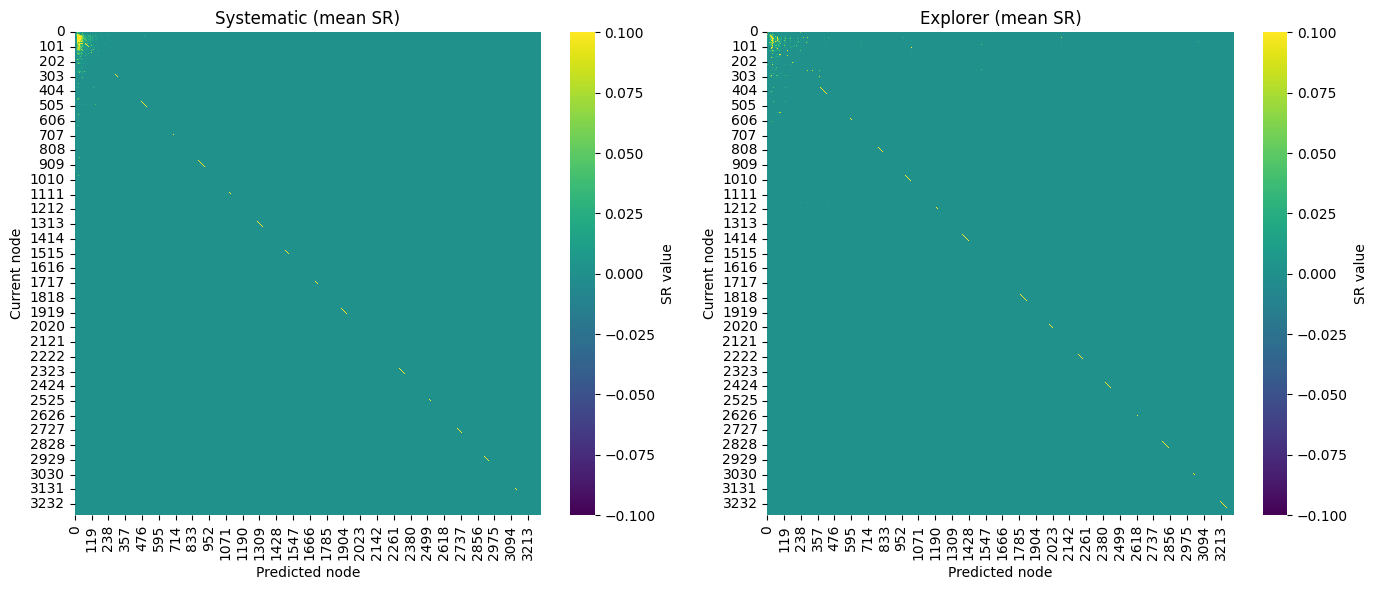

In [10]:

def mean_sr(group_ids):
    mats = []
    for mid in group_ids:
        try:
            mats.append(sr_for_mouse(mid))
        except Exception:
            pass
    if not mats:
        raise RuntimeError("No SR matrices computed for group.")
    return np.mean(mats, axis=0)

explorers = df[df["style"]=="Explorer"].index.tolist()
systematics = df[df["style"]=="Systematic"].index.tolist()

M_ex_mean = mean_sr(explorers)
M_sy_mean = mean_sr(systematics)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.heatmap(M_sy_mean, cmap="viridis", robust=True, cbar_kws={"label":"SR value"})
plt.title("Systematic (mean SR)")
plt.xlabel("Predicted node")
plt.ylabel("Current node")

plt.subplot(1,2,2)
sns.heatmap(M_ex_mean, cmap="viridis", robust=True, cbar_kws={"label":"SR value"})
plt.title("Explorer (mean SR)")
plt.xlabel("Predicted node")
plt.ylabel("Current node")

plt.tight_layout()
plt.show()


## 10) Sparsity index on SR (robust)
We exclude the diagonal to avoid trivial self-prediction dominating.


In [21]:

# Use 'M_ex' or 'M_sy' or group means above
M = M_ex_mean  # change to M_sy_mean if you want

M_no_diag = M.copy()
np.fill_diagonal(M_no_diag, 0)

thr = np.mean(M_no_diag)
sparsity_index = float(np.sum(M_no_diag > thr) / (M_no_diag.shape[0] ** 2))

print(f"Sparsity Index: {sparsity_index:.5f}")

# Heuristic: lower sparsity -> more concentrated predictive map (systematic)
if sparsity_index < 0.05:
    print("Behavior Categorization (heuristic): Systematic-like")
else:
    print("Behavior Categorization (heuristic): Explorer-like")


NameError: name 'M_ex_mean' is not defined